***Text Classification***

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score

- importing dataset

In [7]:
data = pd.read_csv('synthetic_text_data.csv')
data.head()

,text,label
0,Artificial intelligence is advancing in health...,Technology
1,Football fans are excited about the upcoming W...,Sports
2,New policies regarding climate change have spa...,Politics
3,The latest blockbuster movie has shattered box...,Entertainment
4,Quantum computing promises to revolutionize in...,Technology


- now put the text and label in a variables

In [11]:
X = data['text']
y = data['label']

X.describe, y.describe()

(<bound method NDFrame.describe of 0     Artificial intelligence is advancing in health...
 1     Football fans are excited about the upcoming W...
 2     New policies regarding climate change have spa...
 3     The latest blockbuster movie has shattered box...
 4     Quantum computing promises to revolutionize in...
                             ...                        
 80    AI is enhancing customer experiences in retail...
 81    Politicians are debating the pros and cons of ...
 82    Television networks are trying to adapt to the...
 83    New wearable technologies are improving health...
 84    Local sports leagues are organizing tournament...
 Name: text, Length: 85, dtype: str>,
 count             85
 unique             4
 top       Technology
 freq              30
 Name: label, dtype: object)

- Train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((68,), (68,), (17,), (17,))

- Text processing (converting text to numerical data)

In [15]:
vectorizer = CountVectorizer()
X_train_vector = vectorizer.fit_transform(X_train)
X_test_vector = vectorizer.transform(X_test)

- Train the model

In [17]:
model = MultinomialNB()
model.fit(X_train_vector, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


- Making predictions

In [19]:
y_pred = model.predict(X_test_vector)
y_pred

array(['Politics', 'Technology', 'Technology', 'Politics',
       'Entertainment', 'Entertainment', 'Technology', 'Sports',
       'Technology', 'Politics', 'Politics', 'Technology', 'Sports',
       'Technology', 'Technology', 'Politics', 'Entertainment'],
      dtype='<U13')

- Evaluating the model

In [29]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy*100}%")

Accuracy: 88.23529411764706%


- Plotting confusion matrix

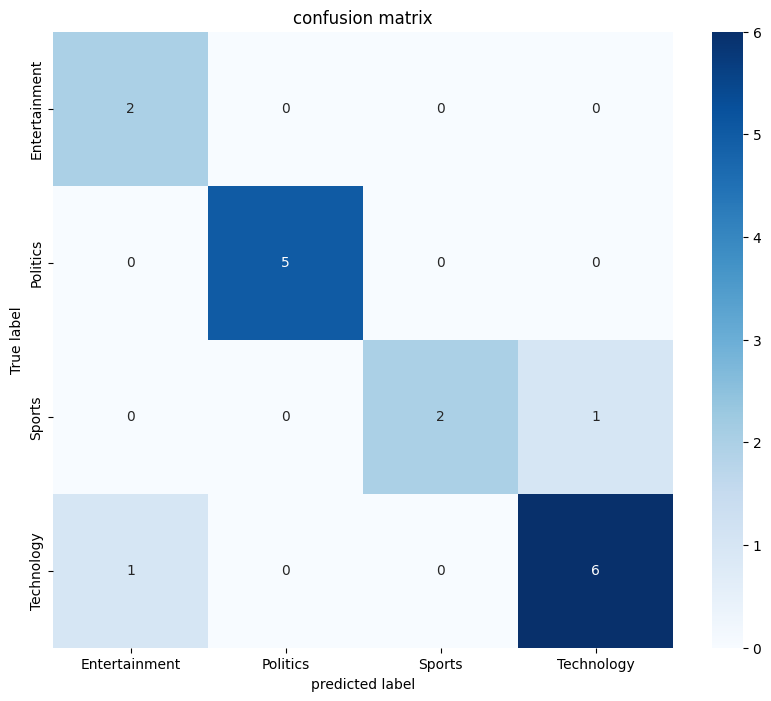

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

class_label = np.unique(y_test)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_label, yticklabels=class_label)
plt.title("confusion matrix")
plt.xlabel('predicted label')
plt.ylabel('True label')
plt.show()

- Prediction on unseen data

In [ ]:
user_input = ("I love artificial intelligence and machine learning")

vectorized_user_input = vectorizer.transform([user_input])
predicted_label = model.predict(vectorized_user_input)
print("Model predicted: ", predicted_label)

Model predicted:  ['Technology']


***At last we can see that model predicted technology category for the unseen data correctly.***